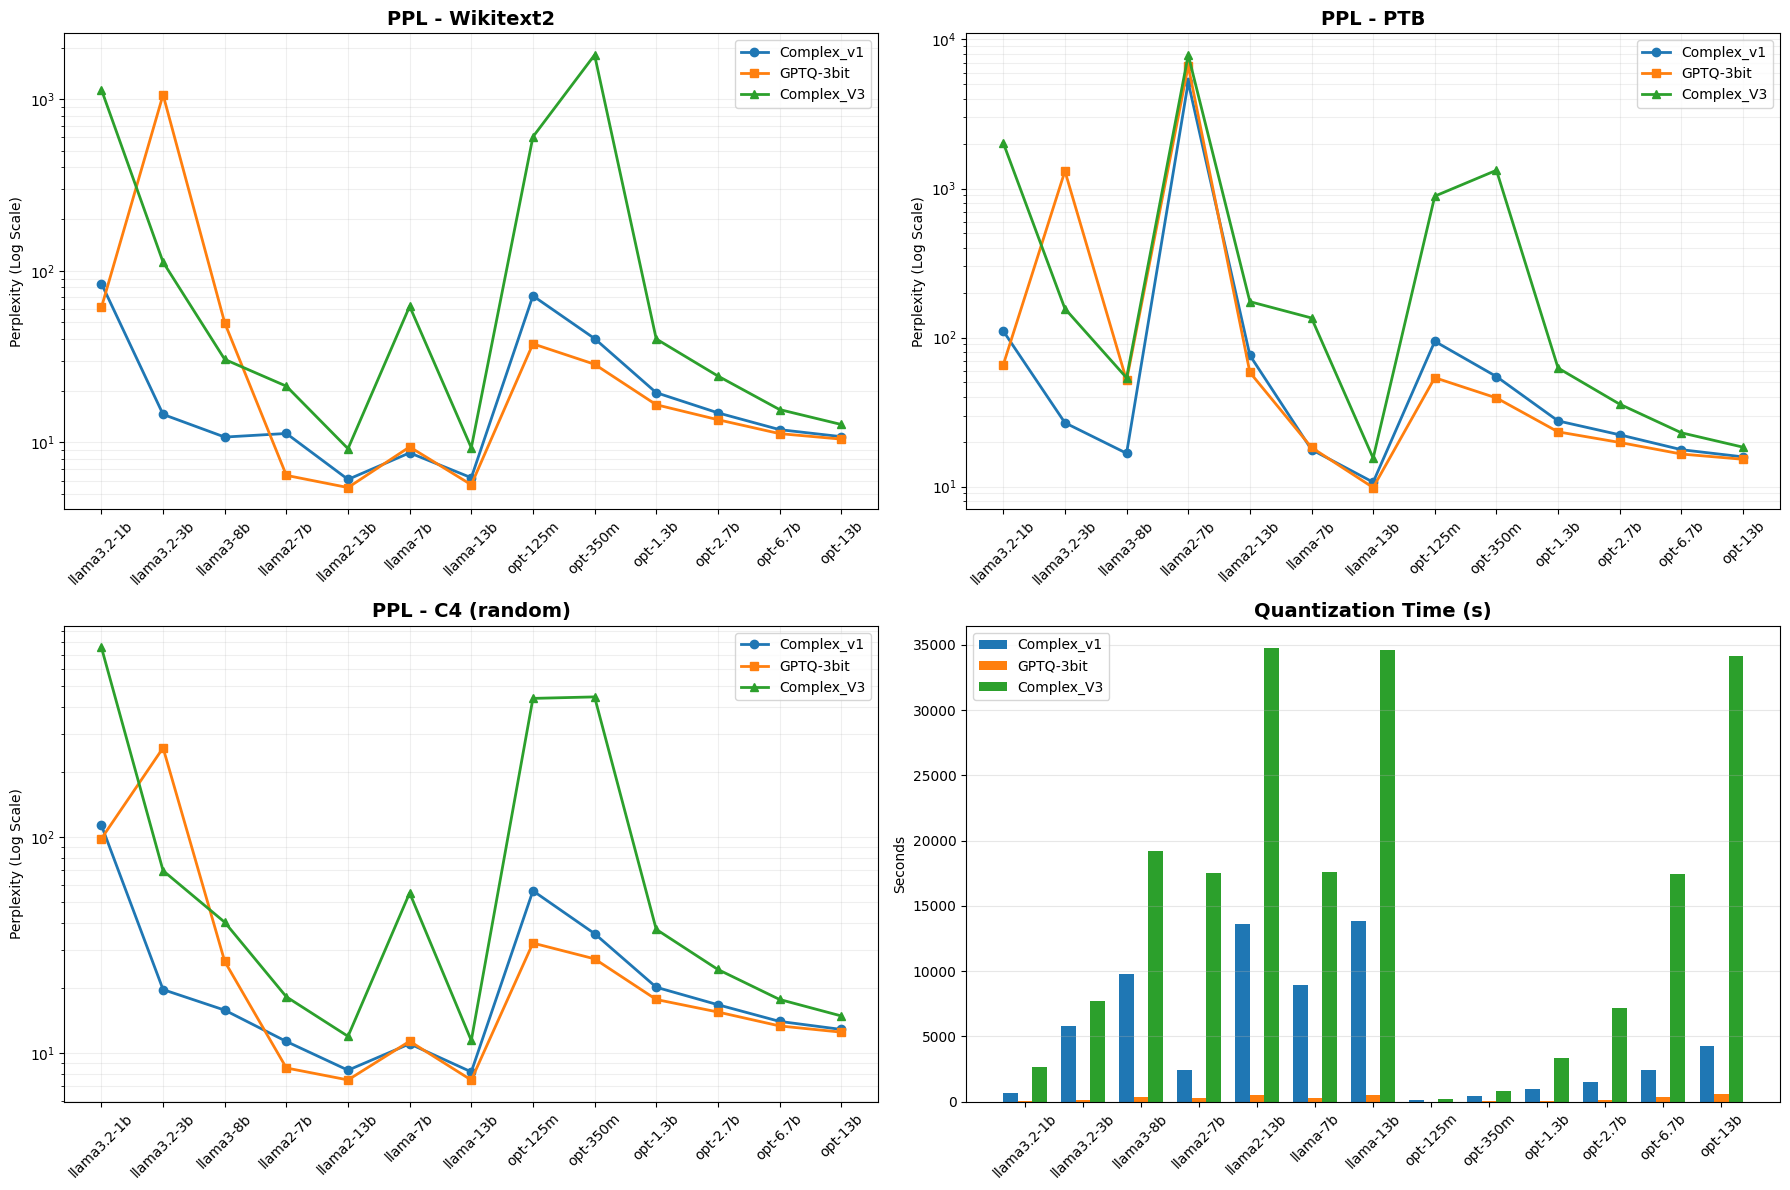

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. 数据整理 ---
# 模型列表 (取并集)
models = [
    'llama3.2-1b', 'llama3.2-3b', 'llama3-8b', 'llama2-7b', 'llama2-13b', 
    'llama-7b', 'llama-13b', 'opt-125m', 'opt-350m', 'opt-1.3b', 'opt-2.7b', 
    'opt-6.7b', 'opt-13b'
]

# PPL - Wikitext2
v1_wiki = [84.29, 14.57, 10.75, 11.28, 6.09, 8.70, 6.23, 71.49, 40.30, 19.50, 14.88, 11.88, 10.81]
gptq_wiki = [61.23, 1061.36, 49.73, 6.43, 5.46, 9.42, 5.67, 37.56, 28.55, 16.59, 13.57, 11.26, 10.46]
v3_wiki = [1136.47, 112.40, 30.47, 21.28, 9.20, 62.17, 9.31, 603.64, 1810.26, 40.09, 24.39, 15.55, 12.73]

# PPL - PTB
v1_ptb = [110.67, 26.82, 16.74, 5160.91, 76.08, 17.72, 10.71, 94.38, 54.78, 27.60, 22.27, 17.70, 15.84]
gptq_ptb = [65.75, 1308.94, 51.60, 6649.49, 58.45, 18.31, 9.86, 53.82, 39.37, 23.31, 19.79, 16.55, 15.26]
v3_ptb = [2022.51, 156.28, 53.70, 7871.32, 174.25, 135.38, 15.54, 888.97, 1325.65, 62.46, 35.74, 22.98, 18.40]

# PPL - C4
v1_c4 = [113.38, 19.64, 15.77, 11.29, 8.31, 11.01, 8.16, 56.35, 35.68, 20.14, 16.71, 13.99, 12.84]
gptq_c4 = [98.38, 259.05, 26.52, 8.51, 7.49, 11.32, 7.48, 32.26, 27.26, 17.67, 15.46, 13.33, 12.47]
v3_c4 = [756.04, 69.85, 40.29, 18.18, 11.93, 55.09, 11.41, 439.09, 446.12, 37.34, 24.34, 17.68, 14.83]

# Time
v1_time = [702.56, 5825.18, 9785.67, 2402.40, 13634.99, 8941.24, 13832.04, 162.84, 453.47, 951.91, 1497.77, 2442.37, 4302.86]
gptq_time = [70.56, 163.58, 336.78, 288.20, 513.21, 282.49, 508.88, 14.20, 37.96, 90.99, 167.11, 342.25, 618.98]
v3_time = [2692.71, 7711.08, 19184.65, 17547.30, 34717.83, 17575.57, 34608.81, 230.65, 827.80, 3326.73, 7143.89, 17469.69, 34128.08]

# --- 2. 绘图 ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# 定义画图函数
def plot_ppl(ax, data_v1, data_gptq, data_v3, title):
    ax.plot(models, data_v1, marker='o', label='Complex_v1', linewidth=2)
    ax.plot(models, data_gptq, marker='s', label='GPTQ-3bit', linewidth=2)
    ax.plot(models, data_v3, marker='^', label='Complex_V3', linewidth=2)
    ax.set_yscale('log') # 使用对数坐标
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Perplexity (Log Scale)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.legend()

# 图1: Wikitext2
plot_ppl(axes[0, 0], v1_wiki, gptq_wiki, v3_wiki, 'PPL - Wikitext2')

# 图2: PTB
plot_ppl(axes[0, 1], v1_ptb, gptq_ptb, v3_ptb, 'PPL - PTB')

# 图3: C4
plot_ppl(axes[1, 0], v1_c4, gptq_c4, v3_c4, 'PPL - C4 (random)')

# 图4: Time (柱状图)
x = np.arange(len(models))
width = 0.25
axes[1, 1].bar(x - width, v1_time, width, label='Complex_v1')
axes[1, 1].bar(x, gptq_time, width, label='GPTQ-3bit')
axes[1, 1].bar(x + width, v3_time, width, label='Complex_V3')
axes[1, 1].set_title('Quantization Time (s)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Seconds')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
import torch
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from datasets import load_from_disk

def calculate_perplexity(model_path, dataset_name="wikitext", dataset_config="wikitext-2-raw-v1", device="cuda"):
    # 1. 加载模型和分词器
    print(f"Loading model from {model_path}...")
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_path, 
        device_map="auto", 
        torch_dtype=torch.float16, 
        trust_remote_code=True
    ).eval()

    # 2. 加载数据集 (如果是本地文件，可以修改为 load_dataset('text', data_files={'test': 'path/to/wiki.test.raw'}))
    print(f"Loading dataset {dataset_config}...")
    #test_data = load_dataset(dataset_name, dataset_config, split="test")
    #data=load_from_disk('/data/xjh/dataset/wikitext-2-raw-v1')
    data=load_from_disk('/data/xjh/dataset/wikitext-2-v1')
    traindata = data['train']
    test_data  = data['test']
    # 将所有文本拼接在一起
    encodings = tokenizer("\n\n".join(test_data["text"]), return_tensors="pt")

    # 3. 计算 PPL
    # Qwen 的 max_position_embeddings 通常较大，可以根据显存调整 stride
    max_length = 2048#model.config.max_window_size if hasattr(model.config, "max_window_size") else 2048
    stride = 512
    seq_len = encodings.input_ids.size(1)

    nlls = []
    prev_end_loc = 0
    
    print(f"Calculating PPL (Total tokens: {seq_len})...")
    
    for begin_loc in tqdm(range(0, seq_len, stride)):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc  # 这一步跳过的 token 数量（避免重复计算）
        
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        
        # 我们只计算 trg_len 部分的 loss，前面的部分作为 context
        target_ids[:, :-trg_len] = -100

        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            # loss 是交叉熵损失的均值
            neg_log_likelihood = outputs.loss

        nlls.append(neg_log_likelihood * trg_len)

        prev_end_loc = end_loc
        if end_loc == seq_len:
            break

    ppl = torch.exp(torch.stack(nlls).sum() / end_loc)
    return ppl.item()

if __name__ == "__main__":
    # --- 配置区域 ---
    LOCAL_MODEL_PATH = "/data/xjh/model_weight/qwen/Qwen3-4B"  # 替换为你本地模型的路径
    # 如果 wikitext 也是本地文件，请修改 load_dataset 部分
    # ----------------
    
    try:
        ppl = calculate_perplexity(LOCAL_MODEL_PATH)
        print(f"\nFinal Perplexity: {ppl:.4f}")
    except Exception as e:
        print(f"Error: {e}")

Loading model from /data/xjh/model_weight/qwen/Qwen3-4B...


Loading checkpoint shards: 100%|██████████| 3/3 [00:01<00:00,  2.41it/s]


Loading dataset wikitext-2-raw-v1...


Token indices sequence length is longer than the specified maximum sequence length for this model (309009 > 131072). Running this sequence through the model will result in indexing errors


Calculating PPL (Total tokens: 309009)...


 99%|█████████▉| 600/604 [01:24<00:00,  7.14it/s]



Final Perplexity: 10.3711


In [ ]:
import torch
import math
import time

def fast_n_by_n_block_svd_quant(matrix: torch.Tensor, n: int = 4, n_bits_param: int = 4, quantizer=None) -> torch.Tensor:
    """
    通用 n*n 块 SVD 量化方案
    :param matrix: 输入的大矩阵
    :param n: 块大小 (n*n)
    :param n_bits_param: U, V 矩阵参数的量化比特数
    :param quantizer: 外部传入的量化器对象 (需实现 fit 和 quantize)
    """
    tick = time.time()
    rows, cols = matrix.shape
    if rows % n != 0 or cols % n != 0:
        raise ValueError(f"Matrix dimensions must be divisible by {n}.")

    # 1. 分块处理 (Batching)
    h_blocks, w_blocks = rows // n, cols // n
    blocks = matrix.view(h_blocks, n, w_blocks, n)
    blocks = blocks.permute(0, 2, 1, 3).reshape(-1, n, n)
    num_blocks = blocks.shape[0]

    # 2. 批量 SVD
    U, S, Vh = torch.linalg.svd(blocks)
    V = Vh.transpose(-2, -1)

    # 3. 行列式修正 (Determinant Correction)
    # 强制使 U, V 属于 SO(n)，即 det=1，确保 Cayley 变换有效
    det_u = torch.linalg.det(U)
    U[det_u < 0, :, -1] *= -1
    V[det_u < 0, :, -1] *= -1

    det_v = torch.linalg.det(V)
    V[det_v < 0, :, -1] *= -1
    S[det_v < 0, -1] *= -1 # 符号吸收

    # 4. 使用 Cayley 变换参数化 U 和 V
    # Cayley 公式: Q = (I - A)(I + A)^-1  => A = (I - Q)(I + Q)^-1
    # A 是反对称矩阵 (A^T = -A)，只需要存储上三角 n(n-1)/2 个元素
    def matrix_to_params(Q):
        I = torch.eye(n, device=Q.device).unsqueeze(0)
        # 为防止 I+Q 不可逆（特征值为-1），加入微小扰动
        A = torch.linalg.solve(I + Q + 1e-6 * I, I - Q)
        # 提取严格上三角元素
        triu_indices = torch.triu_indices(n, n, offset=1)
        params = A[:, triu_indices[0], triu_indices[1]]
        return params

    def params_to_matrix(params):
        A = torch.zeros(num_blocks, n, n, device=params.device)
        triu_indices = torch.triu_indices(n, n, offset=1)
        A[:, triu_indices[0], triu_indices[1]] = params
        A = A - A.transpose(-2, -1) # 构造反对称矩阵
        I = torch.eye(n, device=params.device).unsqueeze(0)
        # Q = (I - A)(I + A)^-1
        Q = torch.linalg.solve(I + A, I - A)
        return Q

    # 提取 U, V 的参数
    params_u = matrix_to_params(U)
    params_v = matrix_to_params(V)
    print(f"params_u shape: {params_u.shape}, params_v shape: {params_v.shape}")
    raise Exception("Debug Stop")
    # 5. 参数量化 (类似角度量化)
    # 这里可以使用简单的均匀量化或传入的 quantizer
    def quantize_params(p, bits):
        scale = p.abs().max() + 1e-5
        levels = 2 ** bits
        step = 2 * scale / levels
        p_q = torch.round(p / step) * step
        return p_q

    q_params_u = quantize_params(params_u, n_bits_param)
    q_params_v = quantize_params(params_v, n_bits_param)

    # 重构量化后的 U 和 V
    U_q = params_to_matrix(q_params_u)
    V_q = params_to_matrix(q_params_v)

    # 6. 奇异值 S 的链式比例量化 (Chain-Ratio Quantization)
    if quantizer is not None:
        # S 形状为 (num_blocks, n)
        S_quant = torch.zeros_like(S)
        
        # 量化第一个奇异值 s0
        s0 = S[:, 0:1]
        quantizer.fit(s0)
        S_quant[:, 0:1] = quantizer.quantize(s0)
        
        # 链式量化后续比例: r_i = s_i / s_{i-1}
        last_s = s0
        for i in range(1, n):
            si = S[:, i:i+1]
            ratio = si / (last_s + 1e-9)
            quantizer.fit(ratio)
            r_quant = quantizer.quantize(ratio)
            S_quant[:, i:i+1] = r_quant * S_quant[:, i-1:i] # 基于前一个已量化的值还原
            last_s = si 
        S = S_quant
    else:
        # 降级方案：简单量化
        S = torch.clamp(S, min=1e-5) # 保证比例计算安全

    # 7. 重构矩阵
    # res = U_q @ diag(S) @ V_q^T
    res_blocks = (U_q * S.unsqueeze(1)) @ V_q.transpose(-2, -1)

    # 8. 恢复形状
    quantized_matrix = res_blocks.view(h_blocks, w_blocks, n, n)
    quantized_matrix = quantized_matrix.permute(0, 2, 1, 3).reshape(rows, cols)
    
    print(f"n={n} SVD 量化完成，耗时: {time.time() - tick:.4f}s")
    return quantized_matrix